<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 9 - Bayesian Inference</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                Notebook author: <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objectives
The objectives of this TD are:

A) With a **discrete probability distribution**, understand the basic principles behind bayesian inference:
- Concepts of prior, likelihood, and posterior
- Generative model
- Bayes' rule
- Bayesian inference

B) Understand how to apply those principles to **continuous distributions**

C) **Bayesian reinforcement learning:** Apply continuous bayesian inference to the RL model used with the bandit task that we have seen before

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from bandit_task import BanditTask

%reload_ext autoreload
%autoreload 2

# A) Basic Concepts: Bayesian Inference with discrete world states
You have probably heard about **Bayes' rule** before, but how deeply do you understand each of its components?
Bayes' rule is crucial for understanding perception, and we will use it throughout the course. You may or may not have studied bayesian probability theory before, so this is the occasion to develop your intuition about these very profound concepts.

In this section, we will work through a simple example from the book [*Bayesian Models of Perception and Action*](https://www.cns.nyu.edu/malab/bayesianbook.html)$^{(1)}$. Imagine you are walking down the school corridor and see a shiny floor. Do you assume it is wet, or just a reflection of light? Would you instinctively start walking more cautiously when you see it?

To analyze the situation, we need to break it down into its various possibilities:
- We consider that the floor can have two possible states: **wet** or **dry**
- We can make two possible observations when looking at the floor: it can be **shiny** or **not shiny**.

The figure below shows all components of bayesian inference:
- **A)** Your **observation**: a shiny floor.
- **B)** The probability that a **wet** or a **dry** floor would appear shiny and look like this. This is the **likelihood**.
- **C)** Your knowledge, based on all the floors you have encountered in your life, about how often floors are wet in general. This is your **prior** belief.
- **D)** The judgment you make about this particular floor, by combining your prior knowledge with the likelihood of your observation under each hypothesis. This is your **posterior** belief: *Is this floor wet or dry?*

<img src="images/bayesian_example.png" style="height: 200px; margin-left: 10px;" />

## Step 1: Generative model

The first step in Bayesian modeling is to define the **generative model**, which describes the statistical relationships between the possible world states and the observations. In our example, we only consider two possible world states (**wet** and **dry**), and each can generate two possible observations (**shiny** and **not shiny**). The generative model specifies the probability distributions for all variables involved in the problem.

As an observer, we can already assume many things from our previous life experiences:
- **Base rate:** In general, floors have a 10% probability of being wet.
- **Conditional probability:** If the floor is wet, it has an 80% probability of being shiny.
- **Conditional probability:** If the floor is dry, it has an 40% probability of being shiny.

The diagram below illustrates the _graphical model_. Nodes represent random variables and arrows, statistical influence of one variable on the other. The conditional probabilities are left for you to deduce from the above statements.

<img src="images/generative_model.png" style="height: 200px; margin-left: 10px;" />

Let's define all missing probability distributions (❓) as python variables.

### **Base Rates**
A **base rate** is the probability associated with a possible world state, regardless of the context or any observation you might make. It reflects how often you have encountered wet or dry floors in your life so far.

📝 Define the `base_rates` of each state of the world (regardless of the observation):
- $p(\text{wet})$
- $p(\text{dry})$

In [2]:
# Solution
base_rates = {
    'wet': 0.1,
    'dry': 0.9
}

📝 Define the conditional probabilities $p(\textit{obs}|\textit{state})$ in the `p_obs_given_state` dictionary, in the following order:
- $p(\text{shiny}|\text{wet})$
- $p(\text{not shiny}|\text{wet})$
- $p(\text{shiny}|\text{dry})$
- $p(\text{not shiny}|\text{dry})$

In [3]:
# Solution
p_obs_given_state = {
    'wet': {
        'shiny': 0.8,
        'not_shiny': 0.2
    },
    'dry': {
        'shiny': 0.4,
        'not_shiny': 0.6
    }
}

## Step 2: Inference

Now that we have defined the alterative hypotheses on the possible states of the floor (_wet_ or _dry_), your priors for each of them, and their likelihoods for all possible observations, let's perform **inference**.

<img src="images/inference.png" style="height: 150px; margin-left: 10px;" />

### a) Observation
Inference is done when we make an **observation**, and we wonder what world state it is the result of.

> **_Observation:_** Suppose that the observer **sees the floor as shiny**.

📝 Define the observation `obs` here. In this discrete example, we will set the observations to either `'shiny'` or `'not_shiny'`

In [4]:
obs = 'shiny'

What can they infer on the actual **state** of the floor (i.e. the probability of it actually being wet)?

### b) Hypothesis
We consider two hypotheses about the state of the world that could explain the shininess of the floor:
- The floor is wet
- The floor is dry (and it shines for some other reason)

We have to consider both hypotheses one after the other in our calculation. Let's say that we first consider the following hypothesis:
 - __*Hypothesis*__: The floor is **wet**.

📝 Set the `hypothesis` for our example (possible values are `'wet'` or `'dry'`)

In [5]:
hypothesis = 'wet'

### c) Prior
We have previous experience in this world. Indeed, we have seen many floors in our life and they were more or less often wet. This has given us a prior belief about the plausibility of our *wet* hypothesis.

📝 Set the **prior belief** about the *wet floor hypothesis*, based on the `base_rates` that you have defined in the generative model.
> ⚠️ From this point on, don't write `'wet'` or `'shiny'` as literal strings in your code. Instead, use the `obs` and `hypothesis` variables you have defined to represent these values. Always refer to the **variable names** in your code.

In [6]:
# Solution
prior = base_rates[hypothesis]
prior

0.1

### d) Likelihood
Once we consider a hypothesis, we can ask ourselves how well it explains the observation that we just made. It is another way of saying, for example, *"If the floor were actually wet, what is the probability that I would see this shiny reflection on its surface?"*. When we formulate the likelihood of a **hypothesis**, we consider that the world is in a certain state, and then we ask how probable the observed outcome is.
> _Notes:_
> - The notion of likelihood completely disregards any prior knowledge about how often floors tend to be wet in general. It is a **local** probability, which is only valid under the assumption that the world is in a certain state.
> - _(More technical note):_ The likelihood $\mathcal{L}(s_\text{hyp}; x_\text{obs})$ is defined as a function over hypothetical world states $s_\text{hyp}$, for a fixed observation $x_\text{obs}$. It may seem to be "backwards", but it is important to understand that likelihood is a function of the state $s_\text{hyp}$ (for a fixed $x_\text{obs}$), even though it is defined as the probability of observing $x_\text{obs}$ given a state $s_\text{hyp}$: $$\mathcal{L}(s_\text{hyp}; x_\text{obs}) \equiv p(x_\text{obs}|s_\text{hyp})$$
> - Notation:
>   - $s_\text{hyp}$: the hypothesis about the state of the world (wet or dry)
>   - $x_\text{obs}$: the observation (shiny or not shiny)
>   - $\mathcal{L}(s_\text{hyp}; x_\text{obs})$: the likelihood of the hypothesis $s_\text{hyp}$ if we consider the observation $x_\text{obs}$

📝 Define the likelihood that it is the wetness of the floor that explains its shininess. For this, you will need the `p_obs_given_state` that you defined in the generative model.

In [7]:
# Solution
likelihood = p_obs_given_state[hypothesis][obs]
likelihood

0.8

### e) Finding the posterior using Bayes' rule

Now that we have prior knowledge, made an observation, considered a hypothesis, computed its likelihood, we can update our prior knowledge and get the **posterior**.

We use **Bayes' rule** as a formula to update the prior belief and take into consideration the observation:

$$
\underbrace{p(s_\text{hyp}|x_\text{obs})}_\text{posterior} = \frac{\overbrace{p(x_\text{obs}|s_\text{hyp})}^\text{likelihood}\overbrace{p(s_\text{hyp})}^\text{prior}}{p(x_\text{obs})}
$$

Let's break this down with our example. We are evaluating the probability that the floor is _wet_, given that we see it _shiny_.  
- In other words, we are looking for $p(\text{wet}|\text{shiny})$, the **posterior** that is informed by the obsevation.
- This probability is proportional to the **likelihood** of any wet floor to be perceived as shiny, $p(\text{shiny}|\text{wet})$, modulated by the how often we encounter wet floors in general $p(\text{wet})$ (our **prior**).
- This numerator is equivalent to the probability of seeing a _wet_ AND _shiny_ floor (also known as _joint probability_)
- To get the posterior, we need to divide the joint probability by the probability of seeing a shiny floor in general $p(\text{shiny})$ (**normalizing constant**)

Let's rewrite the equation with our example:
$$
p(\text{wet}|\text{shiny}) = \frac{p(\text{shiny}|\text{wet}) \cdot p(\text{wet})}{p(\text{shiny})}
$$

The denominator $p(\text{shiny})$ is called the **normalization constant** and represents the probability of seeing a shiny floor in all possible world states. This piece of information isn't given to you, but I let you think about how you can calculate it. Don't hesitate to discuss it with your neighbor if you haven't done this before.

📝 Compute the normalization constant `p_obs` ($p(\text{shiny})$), using `base_rates`, `p_obs_given_state` and your knowledge about probability theory.

In [8]:
# Solution
p_obs = p_obs_given_state['wet']['shiny'] * base_rates['wet'] + p_obs_given_state['dry']['shiny'] * base_rates['dry']
p_obs

0.44000000000000006

📝 Compute the posterior for our example. Reuse the `observation`, `prior`, `hypothesis`, `likelihood` and `p_obs` variables defined previously.

In [9]:
# Solution
posterior = likelihood * prior / p_obs
posterior

0.18181818181818182

📝 Complete the `bayesian_inference` function below. It takes as an input:
- An `observation` (as a string: 'shiny' or 'not_shiny')
- the `priors` (the dictionary you defined above)
- the `likelihoods` (the dictionary you defined above)

It then computes and returns the `posteriors` dictionary. The latter has exactly the same format as the priors, except that the probability values will have changed. 

### 💪 Updating both priors all at once
📝 Based on an observation, we are actually able to update the entire prior distribution over world states. In this optional exercise, you can complete the `bayesian_inference` function, that taks as an argument an `observation` (string) and the `priors` (a dictionary in the same format as the `base_rates`). It then updates the beliefs and returns the `posteriors` as a dictionary, also in the same format as the `base_rates`.

In [10]:
# Solution
def bayesian_inference(observation: str, priors: dict, p_obs_given_state: dict = p_obs_given_state) -> dict:
    posteriors = {}   # Create the output dictionary
    hypotheses = priors.keys()  # The keys of the priors dictionary are ['wet', 'dry']

    # Compute a posterior probability for each hypothesis
    for hypothesis in hypotheses:
        # Your code here
        prior = priors[hypothesis]
        likelihood = p_obs_given_state[hypothesis][observation]
        normalization_constant = sum([p_obs_given_state[h][observation] * priors[h] for h in hypotheses])

        posteriors[hypothesis] = likelihood * prior / normalization_constant

    return posteriors

Imagine that you **observe** a _shiny_ floor, just as in the example we gave. 

📝 Set the `observation` variable to the appropriate value and call your `bayesian_inference` function to compute the posterior beliefs given this new information. You have unit tests to check that your implementation is correct.

In [11]:
# Solution
observation = 'shiny'

priors = base_rates

posteriors = bayesian_inference(observation, priors)
print(posteriors)

# Unit tests
assert isinstance(posteriors, dict), "Your posterior should be a dictionary"
assert set(posteriors.keys()) == {'wet', 'dry'}, "Your posteriors dictionary should have the same format as the priors."
assert math.isclose(posteriors['wet'], 0.182, abs_tol=0.001), "Incorrect posterior value for the 'wet' hypothesis"
assert math.isclose(posteriors['dry'], 0.818, abs_tol=0.001), "Incorrect posterior value for the 'dry' hypothesis"
print("OK 👌")

{'wet': 0.18181818181818182, 'dry': 0.8181818181818181}
OK 👌


📝 Call your `bayesian_inference` function with the other observation and see how the posterior changes

In [12]:
# Solution
new_observation = 'not_shiny'

bayesian_inference(new_observation, priors)

{'wet': 0.03571428571428572, 'dry': 0.9642857142857143}

📝 Change the prior entirely and see how it impacts the inference.

In [13]:
# Solution
new_prior = {
    'wet': 0.5,
    'dry': 0.5
}
observation = 'shiny'

bayesian_inference(observation, new_prior)

{'wet': 0.6666666666666666, 'dry': 0.3333333333333333}

## B) Bayesian Inference with continuous world states

Now what if the belief is not about two discrete options, but about a **continuous value**?

A very common way to model probability for continuous values is with a **Normal (Gaussian) Distribution**.

As you may know, probabilities for continuous random variables are defined with **probability density functions**. The normal distibution, denoted $\mathcal{N}(\mu, \sigma^2)$, is parametrized by:
- A mean ($\mu$)
- A variance ($\sigma^2$)

And its density function is given by:
$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}}$$

The `GaussianBelief` class implements beliefs as normal distributions. Its constructor takes in a mean, a standard deviation (to make it easier for us), and a name.

📝 Implement the `probability_density` method of the `GaussianBelief` class, using the equation given above.

In [14]:
# Solution
class GaussianBelief:
    def __init__(self, mean: float, std: float, name: str = ""):
        self.mean = mean
        self.std = std
        self.var = std ** 2
        self.name = name

    def probability_density(self, x: float) -> float:
        # First exercise
        return (1 / (self.std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - self.mean) / self.std) ** 2)

    def __mul__(self, other) -> 'GaussianBelief':
        # To do in the next exercise
        var = 1 / (1 / self.var + 1 / other.var)
        mean = var * (self.mean / self.var + other.mean / other.var)
        return GaussianBelief(mean, np.sqrt(var), name=f"Posterior")

    def plot(self):
        range = (self.mean - 4 * self.std, self.mean + 4 * self.std)
        x = np.linspace(*range, 100)
        y = self.probability_density(x)
        plt.plot(x, y, label=str(self))
        plt.title(f"Probability Density Function")
        plt.xlabel("s")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()

    def __str__(self):
        return f"{self.name} (m={self.mean:.2f}, std={self.std:.2f})"

    def __repr__(self):
        return f"GaussianBelief(mean={self.mean:.3f}, std={self.std:.3f})"

📝 Instantiate a standard normal distribution $\mathcal{N}(0, 1)$ and call the `plot()` method to see if you implemented the equation correctly.

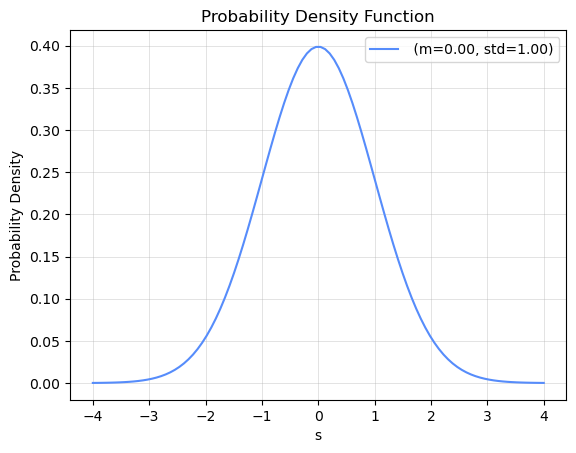

In [15]:
# Solution
standad = GaussianBelief(0, 1)
standad.plot()

### Context
📖 Let's imagine that you are participating in an experiment where you are in a dark room, and that you hear a sound coming from somewhere in front of you. You are asked to give an estimation of the angular direction of the source of the sound.
- The center corresponds to position 0
- To the left is negative
- To the right is positive

### Prior
Let's first model your belief about the location of the sound source. In bayesian inference, we never think of our hypothesis as "one true location", but as a probability distribution over possible location, with a certain degree of certainty.
$$
p(s) = \mathcal{N}(\mu, \sigma^2_s)
$$
📖 You presuppose that the source of the sound ist most probably straight in front of you (at position 0), with a decreasing probability of falling on either side of the center. This corresponds to a gaussian belief.

📝 Initialize your prior as a `GaussianBelief`, where you expect the source to come from anywhere around the center, with a standard deviation of 0.4. Give the name "Prior" to the constructor.

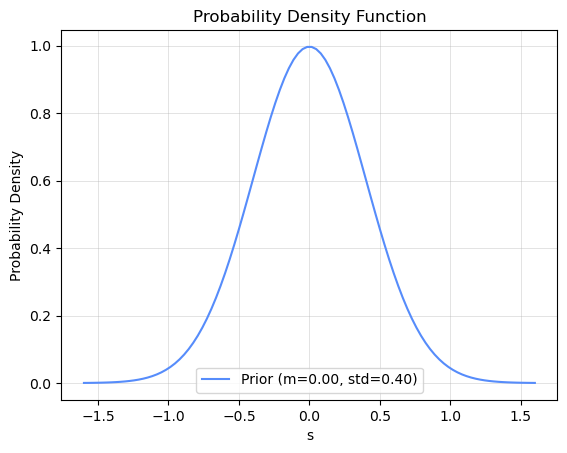

In [16]:
# Solution
prior = GaussianBelief(mean=0, std=0.4, name="Prior")
prior.plot()

💭How do you interpret the two parameters of the prior belief?
- Mean: a mean of 0 means that you expect the sound to come from the center
- Standard deviation: what does it mean to have a higher or lower standard deviation (or variance) here?

### Observation
Now you hear a sound that seems to come from position $0.5$.

📝 Set the value of the observation $x$.

In [17]:
# Solution
x = 0.5

### Likelihood
You know, however that your perceptual system is imprecise, and that even though you would say that the sound comes from position 0.5, you are aware the actual source may be a little bit off on either side. The likelihood function is there to quantify, for each hypothetical source location $s$, the probability that the sound could have seemed to come from position $x$.
$$
\mathcal{L}(s; x) = p(x|s) = \mathcal{N}(x, \sigma^2)
$$
📝Instantiate a `GaussianBelief` to represent the likelihood of a source located at position $s$ given that you heard a sound coming from $x$. Consider that:
- The source has the maximal probability of being at position $x$
- What you hear is on average off by 0.1 from the actual source position.

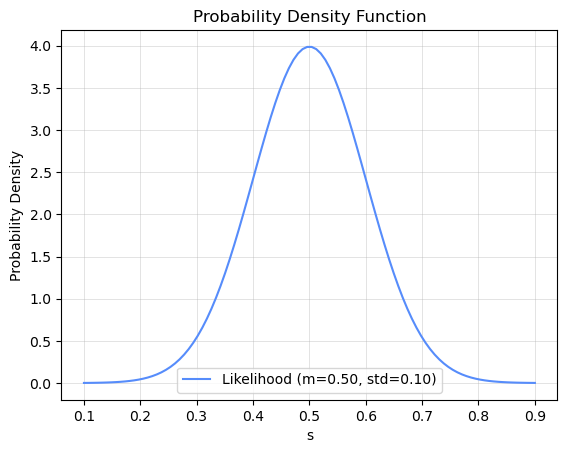

In [18]:
# Solution
likelihood = GaussianBelief(mean=x, std=0.1, name="Likelihood")
likelihood.plot()

This graph shows how probable it is that the source is at position $s$, given what we have heard a sound that seems to come from position $x=0.5$.

💭How do you interpret the two parameters of the likelihood function?
- **Mean**: the likelihood function is centered on the position $x$ of the sound that you heard. It is where the source $s$ is most likely to be.
- **Std**: what does it mean to have a higher or lower standard deviation (or variance) here?

### Bayesian Inference
Let's recap what we have got:
- **Prior**: We had a prior belief about where we would expect the source to be (around the center, at position 0)
- **Obsevation**: We heard a sound that seems to come from position 0.5
- **Likelihood**: We trust our ears to some extent, but we know the source could be more or less 0.1 on either side.

We can plot all those elements on a graph

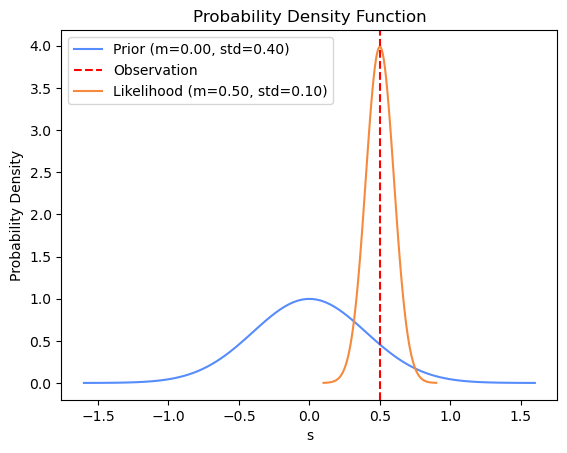

In [19]:
prior.plot()
plt.axvline(x=x, color='red', linestyle='--', label="Observation")
likelihood.plot()

### Bayes' rule
Now how do we combine the prior and the likelihood to get the posterior? We use Bayes' rule:
$$
p(s|x) = \frac{p(x|s)p(s)}{p(x)} = \frac{\text{likelihood} \times \text{prior}}{\text{normalization constant}}
$$

This means that we can compute the posterior by multiplying the prior and the likelihood, and then normalize them. The product of two gaussian distributions is therefore proportional to a new gaussian distribution, so we usually write the posterior like this:
$$
p(s|x) \propto p(x|s)p(s) = \text{likelihood} \times \text{prior}
$$
So now we are considering three gaussians:
- $\text{prior} \sim \mathcal{N}(\mu_\text{prior}, \sigma^2_\text{prior})$
- $\text{likelihood} \sim \mathcal{N}(\mu_\text{likelihood}, \sigma^2_\text{likelihood})$
- $\text{posterior} \sim \mathcal{N}(\mu_\text{posterior}, \sigma^2_\text{posterior})$

Fortunately, have a way to get the mean and standard deviation of the posterior distribution analytically while also taking into account the normalization constant. Here are the formulas you can use:
<div style="display: flex; justify-content: space-between;">
    <div style="width: 48%;">
        $$
        \sigma^2_\text{posterior}  \frac{1}{\frac{1}{\sigma^2_\text{prior}} + \frac{1}{\sigma^2_\text{likelihood}}}
        $$
    </div>
    <div style="width: 48%;">
        $$
        \mu_\text{posterior} = \sigma^2_\text{posterior} \left( \frac{\mu_\text{prior}}{\sigma^2_\text{prior}} + \frac{\mu_\text{likelihood}}{\sigma^2_\text{likelihood}} \right)
        $$
    </div>
</div>

📝Implement the `__mul__` magic method of the `GaussianBelief` class. This method should take as input another `GaussianBelief` object, perform the multiplication and normalization, and return a new `GaussianBelief` object that represents the posterior belief. You can use the formulas above to compute the mean and standard deviation of the posterior belief.
> ⚠️_Note_: After you have implemented the `__mul__` method, you will need to re-execute all the cells in this section in order fot the changes to be effective on the `prior` and `likelihood` objects.

📝Multiply your `prior` belief and your `likelihood` to produce the `posterior` and plot them all on the same graph

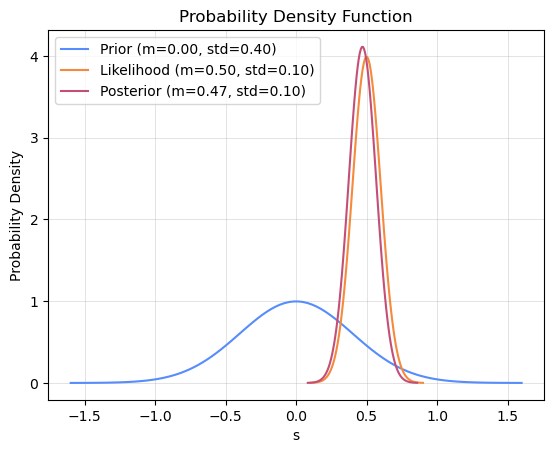

In [20]:
# Solution
posterior = prior * likelihood
prior.plot()
likelihood.plot()
posterior.plot()

### See the effect of the strength of the prior
In the previous example, the posterior almost completely overlapped the likelihood. This is because the prior was very weak (high variance). Let's see what happens if you set a stronger prior.

📝Set the prior to a mean of 0.5 and a much smaller standard deviation and plot the posterior again.

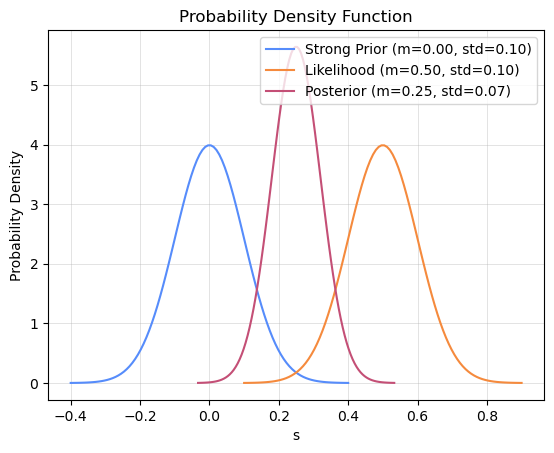

In [21]:
strong_prior = GaussianBelief(mean=0, std=0.1, name="Strong Prior")
new_posterior = strong_prior * likelihood
strong_prior.plot()
likelihood.plot()
new_posterior.plot()

## 💪 Bayesian Reinforcement Learning
In this section, you will discover that you can adapt the Reinforcement learning paradigm on which we have worked so far and make it bayesian. The bayesian model will use the concepts of prior, likelihood, and posterior to learn about the expected rewards of two actions in a bandit task.

#### Generative Model
$$p(\mu_a) = \mathcal{N}(\mu, \sigma^2) \quad a \in {0, 1}$$

The distribution of rewards given a source
$$
p(r_a|\mu_a) =  \mathcal{N}(\mu_a, \sigma^2_\text{reward}) \quad a \in {0, 1}
$$

### Bayesian Inference

Instead of using q-values to model the expected value of each action, we will use a full **gaussian probability distribution**.

Bayesian inference is done **at every trial**:
1. **Prior**: The model has a prior belief about what is the average reward of each arm:
   
   $$p(\mu^0) = \mathcal{N}(\mu^0_\text{prior}, {\sigma^0}^2_\text{prior})$$

   $$p(\mu^1) = \mathcal{N}(\mu^1_\text{prior}, {\sigma^1}^2_\text{prior})$$

3. **Policy**: The model chooses an action from a softmax policy. Instead of comparing two q-values, we compare the means of the prior distributions.

    $$a \sim \text{softmax}(\mu^1_\text{prior}, \mu^0_\text{prior}; \tau)$$
   
4. **Likelihood**: The model will update its beliefs based on the observed rewards, using a Gaussian likelihood function.

    $$\mathcal{L}(\mu^a; r) = \mathcal{N}(r, \sigma_\text{r}^2)$$

   
5. **Posterior**: The model will compute the posterior distribution of the chosen action and update its associated belief

   $$p(\mu^a|r) = \mathcal{N}(\mu^a_\text{post}, {\sigma^a}^2_\text{post})$$

The posterior of trial $t$ becomes the prior of trial $t+1$.

### A new RLModel class
Here is a modified version of the `RLModel` class with which we have worked in the past TDs.

We initialize the `BayesianRLModel` with the following parameters:
- `init_mean`: The initial mean of the prior distribution for both actions (we assume $\mu^0 = \mu^1 = \mu_\text{init}$).
- `init_std`: The initial standard deviation of the prior distribution for both actions (we assume $\sigma^0 = \sigma^1 = \sigma_\text{init}$).
- `reward_std`: The standard deviation of the likelihood distribution ($\sigma_\text{reward}$).
- `temperature`: The temperature of the softmax policy, as usual ($\tau$)

📝 In the `BayesianRLModel` class, implement the `policy` and `update` methods.
- policy: you use the means of the two belief distributions to compute the softmax
- update: Your use the current belief as the prior, you update it and set it as the posterior

In [22]:
class BayesianRLModel:
    def __init__(self, init_mean: float, init_std: float, reward_std: float, temperature: float):
        self.init_mean = init_mean
        self.init_std = init_std
        self.reward_std = reward_std
        self.temperature = temperature
        self.beliefs = [
            GaussianBelief(mean=init_mean, std=init_std, name="Prior_0"),
            GaussianBelief(mean=init_mean, std=init_std, name="Prior_1")
        ]

    def policy(self):
        # Your code here
        mean_1 = self.beliefs[1].mean
        mean_0 = self.beliefs[0].mean
        
        prob = 1 / (1 + np.exp(-(mean_1 - mean_0) / self.temperature))
        return prob

    def update(self, action: int, reward: float):
        # Your code here
        prior = self.beliefs[action]
        likelihood = GaussianBelief(mean=reward, std=self.reward_std)
        posterior = prior * likelihood
        self.beliefs[action] = posterior

    def simulate(self, task, plot=False):
        self.reset()
        actions = []
        probs = []
        beliefs_0 = []
        beliefs_1 = []
        rewards = []
        for trial_rewards in task:
            prob = self.policy()
            action = np.random.binomial(1, prob)
            reward = trial_rewards[action]
            actions.append(action)
            probs.append(prob)
            beliefs_0.append((self.beliefs[0].mean - self.beliefs[0].std, self.beliefs[0].mean + self.beliefs[0].std))
            beliefs_1.append((self.beliefs[1].mean - self.beliefs[1].std, self.beliefs[1].mean + self.beliefs[1].std))
            rewards.append(reward)
            self.update(action, reward)
           
        if plot:
            task.plot()
            plt.plot(probs, label='P(action=1)', color='green')
            x = list(range(len(actions)))
            plt.scatter(x, actions, label='actions', color='red')
            plt.fill_between(x, *zip(*beliefs_0), color='blue', alpha=0.2, label='beliefs_0')
            plt.fill_between(x, *zip(*beliefs_1), color='orange', alpha=0.2, label='beliefs_1')
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            plt.title(f"{plt.gca().get_title()}\nwith {self}\ntotal reward = {sum(rewards):.2f}")
        return np.array(actions, dtype=int), np.array(probs, dtype=float), np.array(rewards, dtype=float)

    def reset(self):
        self.beliefs = [
            GaussianBelief(mean=self.init_mean, std=self.init_std, name="Prior_0"),
            GaussianBelief(mean=self.init_mean, std=self.init_std, name="Prior_1")
        ]

    def __repr__(self):
        return f'BayesianModel(t={self.temperature: .3f})'

📝 Instantiate a `BayesianRLModel` with parameters of your choice and plot its behavior on the Bandit Task.
- You can set `reward_std` to the actual standard deviation of the rewards in your task.

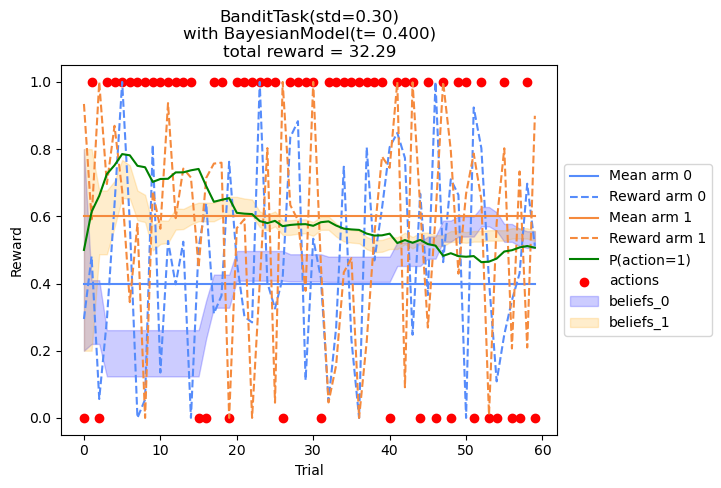

In [23]:
# Solution
model = BayesianRLModel(init_mean=0.5, init_std=0.3, reward_std=0.1, temperature=0.4)

task = BanditTask(mean_0=0.4, mean_1=0.6, std=0.3, n_trials=60)
_ = model.simulate(task, plot=True)

 ### 💪💪 Optional: Thompson Sampling
You can make your BayesianRLModel even smarter by making the stochasticity of the policy depend on the uncertainty of the beliefs. The more uncertain, the more stochastic the policy. This is called **Thompson Sampling**.
You can have a look at the paper by [Schultz and Gershman (2019)$^{(2)}$](https://linkinghub.elsevier.com/retrieve/pii/S0959438818300904) for more details.

📝In a new `ThompsonSamplingRLModel` class, override the `policy` method to implement thompson sampling.
- Instead of having a `temperature` parameter, the model computes the temperature of each trial by combining the uncertainty of the two beliefs.
$$\tau_t = \sqrt{{\sigma^0}^2_t + {\sigma^1}^2_t}$$

In [24]:
class ThompsonSamplingRLModel(BayesianRLModel):
    def __init__(self, init_mean: float, init_std: float, reward_std: float):
        super().__init__(init_mean, init_std, reward_std, temperature=1)

    def policy(self):
        # Your code here
        temperature = np.sqrt(self.beliefs[0].std**2 + self.beliefs[1].std**2)
        prob = 1 / (1 + np.exp(-(self.beliefs[1].mean - self.beliefs[0].mean) / temperature))

        return prob

📝Test your `ThompsonSamplingRLModel` on the same bandit task as before. You can first use the same parameters as the `BayesianRLModel`, and then play around with the parameters.

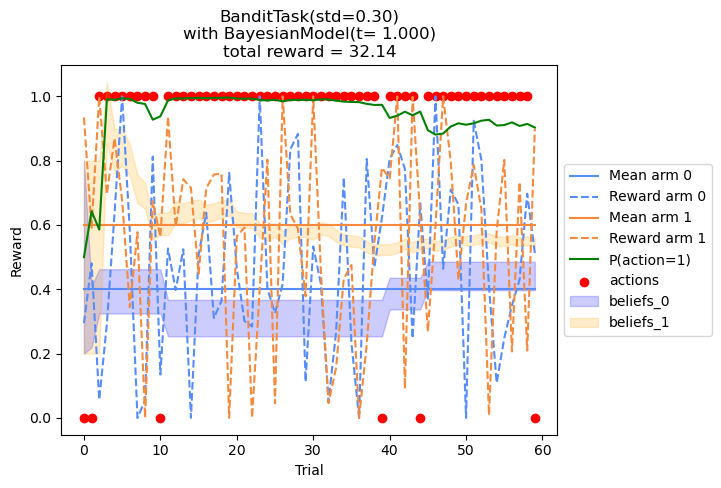

In [25]:
thompson_model = ThompsonSamplingRLModel(init_mean=0.5, init_std=0.3, reward_std=0.1)
_ = thompson_model.simulate(task, plot=True)

## References:
1. Ma, W. J., Kording, K. P., & Goldreich, D. (2023). Bayesian Models of Perception and Action: An Introduction. MIT press.
Available https://www.cns.nyu.edu/malab/bayesianbook.html
2. Schulz, E., & Gershman, S. J. (2019). The algorithmic architecture of exploration in the human brain. Current Opinion in Neurobiology, 55, 7–14. https://doi.org/10.1016/j.conb.2018.11.003

